In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 12 05:42:03 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 12 05:42:03 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def bin_features(list_cols, X, y, dict_monotone_constraints, int_n_bins):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # copy the original
        int_n_bins_tmp = int_n_bins
        
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
        
        # logic for some features
        list_cols_uniform = [
#             'ENG-loan_to_value',
#             'ENG-payment_to_income',
#             'flt_avg_open__tu_pmthx',
#             'flt_wtd_avg_open__tu_pmthx',
#             'flt_avg_closed__tu_pmthx',
#             'flt_wtd_avg_closed__tu_pmthx',
#             'ENG-payment_trend_open',
#             'ENG-payment_trend_closed',
#             'addrchangecount12month__ln',
#             'fltgrossmonthly__income_sum',
        ]
        # logic for ltv
        if col in list_cols_uniform:
            str_prebinning_method = 'uniform'
        else:
            str_prebinning_method = 'cart'
        
        # make sure maximum number of bins are showing
        while True:
            # init
            cls_binning = OptimalBinning(
                name=col,
                dtype='numerical',
                solver='cp',
                monotonic_trend=str_monotonic_trend,
                min_n_bins=int_n_bins_tmp,
                max_n_bins=int_n_bins_tmp,
                prebinning_method=str_prebinning_method,
            )
            # fit
            cls_binning.fit(
                X[col],
                y,
            )
            # assign
            dict_bins[col] = cls_binning

            # transform
            str_col = f'{col}_binned'
            X[str_col] = cls_binning.transform(
                X[col],
                metric='woe',
            )

            # get count unique
            int_n_unique = X[str_col].nunique()
            
            # logic
            if int_n_unique == int_n_bins_tmp:
                break
            else:
                # subtract
                int_n_bins_tmp -= 1
            
            # logic
            if int_n_bins_tmp == 0:
                break
            else:
                pass

        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X

#### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

str_task_tmp = '09_60_in_720'

Project: 20241112-simple-model-test
Task: create_grid
Subtask: 01_60_in_720
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [5]:
str_filename = 'df_holdout.gzip'
str_uri = f's3://{str_project}/{str_task_tmp}/01_data_split/{str_filename}'
df = pd.read_parquet(
    str_uri,
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,request_month,train,valid,test,inform,holdout,data_set
31610,6287434,2022-09-08 03:40:17+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-09-07.gzip,1,1,Georgia,Franchise,Georgia,False,...,1,1,0,2022-09-01,0,0,0,0,1,holdout
32950,6286713,2022-09-20 01:34:05+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-09-19.gzip,1,1,Alabama,Franchise,Alabama,False,...,1,1,0,2022-09-01,0,0,0,0,1,holdout
34174,6286718,2022-09-29 02:45:06+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-09-28.gzip,0,0,Tennessee,Independent,Tennessee,True,...,0,0,0,2022-09-01,0,0,0,0,1,holdout
32357,6287522,2022-09-14 05:29:13+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-09-13.gzip,1,1,Illinois,Franchise,Illinois,True,...,0,0,0,2022-09-01,0,0,0,0,1,holdout
33023,6287424,2022-09-20 22:22:05+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-09-20.gzip,1,1,South Carolina,Independent,North Carolina,True,...,0,0,0,2022-09-01,0,0,0,0,1,holdout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40317,6408804,2022-11-08 01:11:23+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-07.gzip,1,1,Alabama,Franchise,Alabama,False,...,0,0,0,2022-11-01,0,0,0,0,1,holdout
41049,6404526,2022-11-19 01:39:13+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-18.gzip,1,1,Utah,Independent,Louisiana,False,...,1,1,1,2022-11-01,0,0,0,0,1,holdout
40102,6409395,2022-11-03 22:28:01+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-03.gzip,1,1,Washington,Franchise,Washington,False,...,0,0,0,2022-11-01,0,0,0,0,1,holdout
41352,6408000,2022-11-24 03:33:54+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-23.gzip,1,1,Maryland,Franchise,Maryland,True,...,0,0,0,2022-11-01,0,0,0,0,1,holdout


#### List of columns

In [6]:
list_cols = [
    'fltgrossmonthly__income_sum',
    'ENG-loan_to_value',
    'ENG-payment_to_income',
    'dti__app',
    'flt_avg_open__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'fltdowncash__app',
    'fltapproveddowntotal__app',
]

#### Impute

In [7]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

dict_impute['ENG-payment_to_income'] = df['ENG-payment_to_income'].max()
dict_impute['flt_avg_open__tu_pmthx'] = 0
dict_impute['flt_avg_closed__tu_pmthx'] = 0
dict_impute['fltdowncash__app'] = 0
dict_impute['fltapproveddowntotal__app'] = 0

# impute
for key, val in tqdm(dict_impute.items()):
    df[key] = df[key].fillna(val)

100%|██████████| 1138/1138 [00:00<00:00, 2500.44it/s]


#### Monotonic constraints

In [8]:
# get monotonic constraints
dict_monotone_constraints = {
    'fltgrossmonthly__income_sum': -1,
    'ENG-loan_to_value': 1,
    'ENG-payment_to_income': 1,
    'dti__app': 1,
    'flt_avg_open__tu_pmthx': -1,
    'flt_avg_closed__tu_pmthx': -1,
    'flt_wtd_avg_open__tu_pmthx': -1,
    'flt_wtd_avg_closed__tu_pmthx': -1,
    'fltdowncash__app': -1,
    'fltapproveddowntotal__app': -1,
}
dict_bins, list_cols_scorecard, X = bin_features(
    list_cols=list_cols,
    X=df[list_cols].copy(),
    y=df[str_target],
    dict_monotone_constraints=dict_monotone_constraints,
    int_n_bins=5,
)

100%|██████████| 10/10 [00:00<00:00, 12.15it/s]


In [9]:
# show bins
df_tmp = X.copy()
df_tmp['target'] = df[str_target]
list_df = []
for col in tqdm(list_cols_scorecard):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 10/10 [00:00<00:00, 176.83it/s]


,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.081507,0.000000,3125.200000,2917,0.271829,0.456634,1
1,fltgrossmonthly__income_sum_binned,-0.067893,3125.350000,3988.190000,2471,0.230267,0.453258,2
2,fltgrossmonthly__income_sum_binned,0.031602,3988.240000,4688.290000,1740,0.162147,0.428736,3
3,fltgrossmonthly__income_sum_binned,0.040144,4689.390000,7721.240000,3040,0.283291,0.426645,4
4,fltgrossmonthly__income_sum_binned,0.427099,7729.320000,11742.160000,563,0.052465,0.335702,5
4,ENG-loan_to_value_binned,0.619111,0.348839,1.031930,598,0.055726,0.294314,1
3,ENG-loan_to_value_binned,0.261425,1.032296,1.129838,977,0.091045,0.373593,2
2,ENG-loan_to_value_binned,0.100423,1.129910,1.188556,1153,0.107446,0.411969,3
1,ENG-loan_to_value_binned,-0.007086,1.188635,1.308607,3311,0.308545,0.438236,4
0,ENG-loan_to_value_binned,-0.145324,1.308616,2.423510,4692,0.437238,0.472506,5


#### Plot

  0%|          | 0/10 [00:00<?, ?it/s]

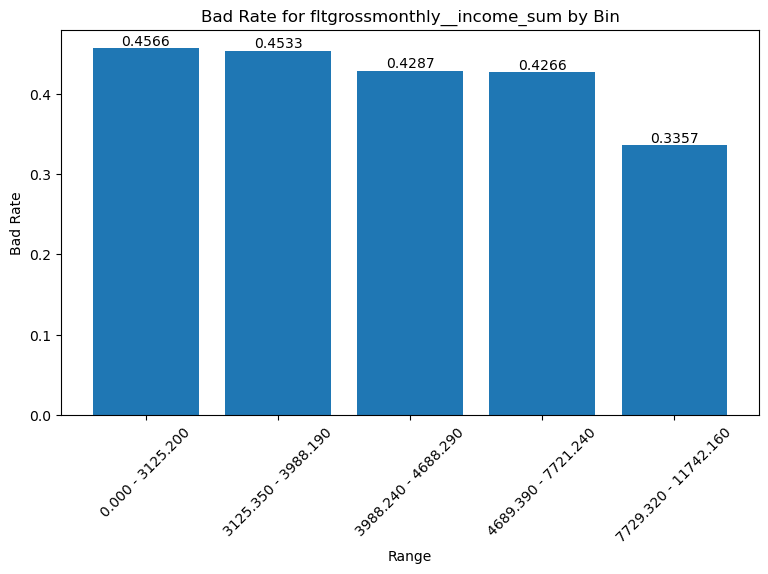

 10%|█         | 1/10 [00:00<00:01,  5.69it/s]

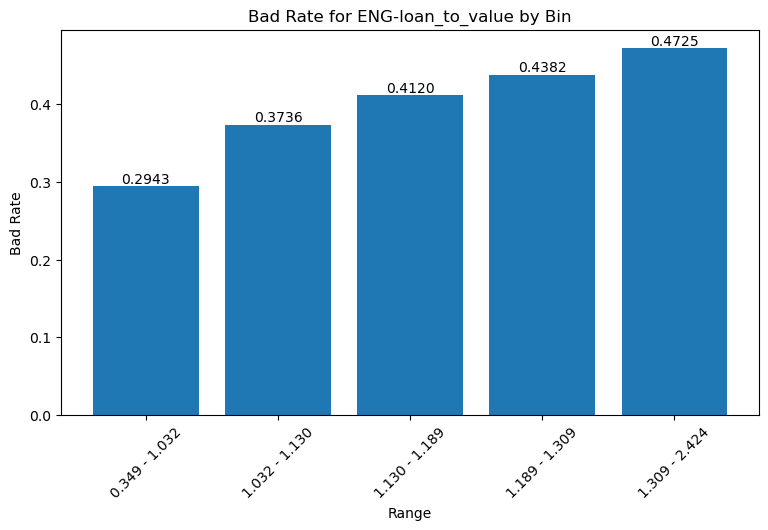

 20%|██        | 2/10 [00:00<00:01,  6.68it/s]

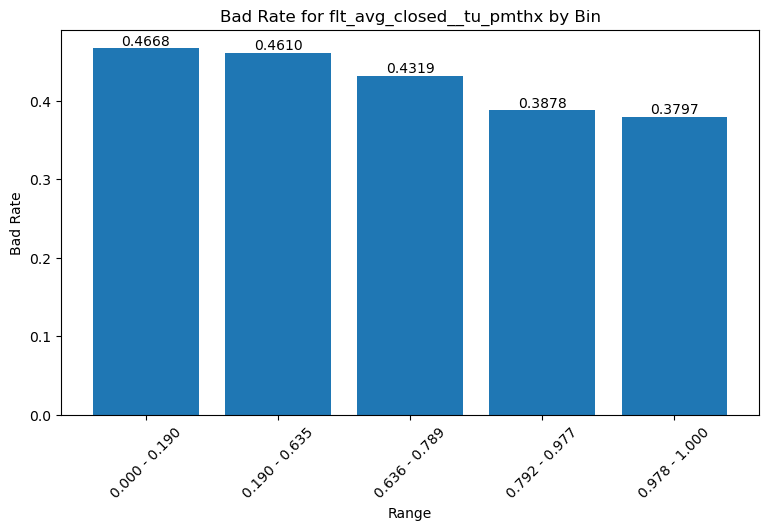

 30%|███       | 3/10 [00:00<00:00,  7.05it/s]

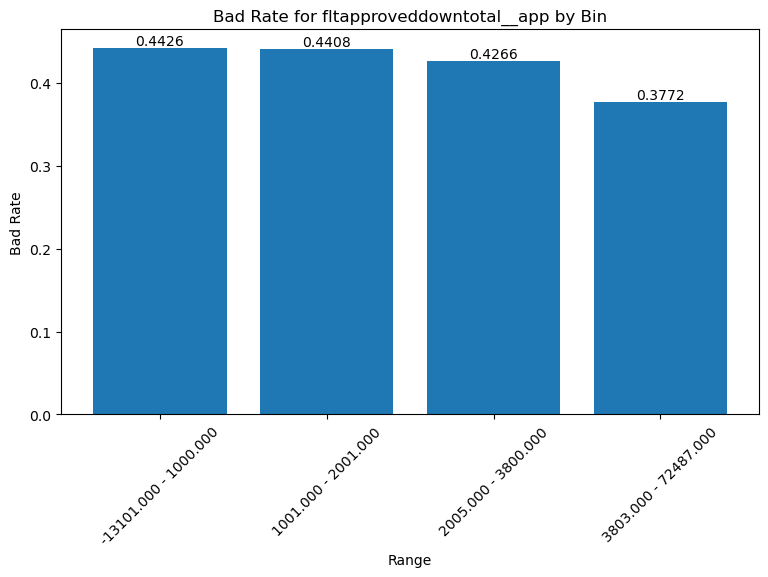

 40%|████      | 4/10 [00:00<00:00,  7.30it/s]

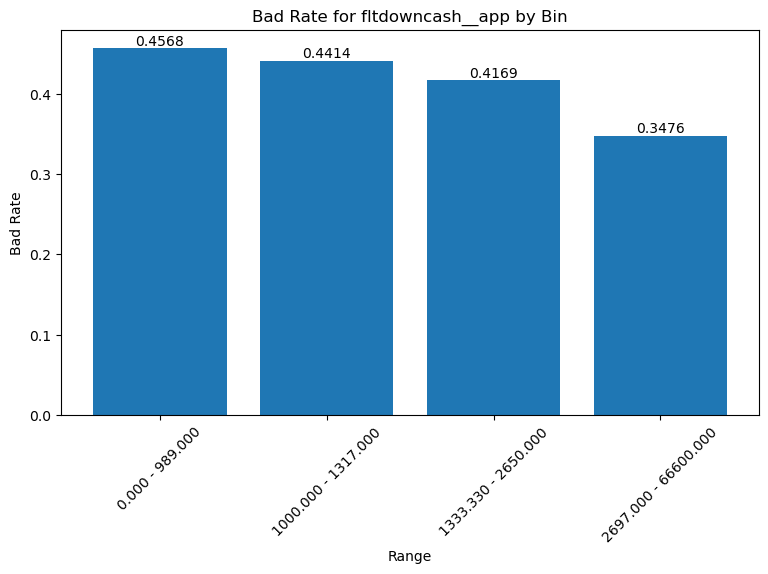

 50%|█████     | 5/10 [00:00<00:00,  7.45it/s]

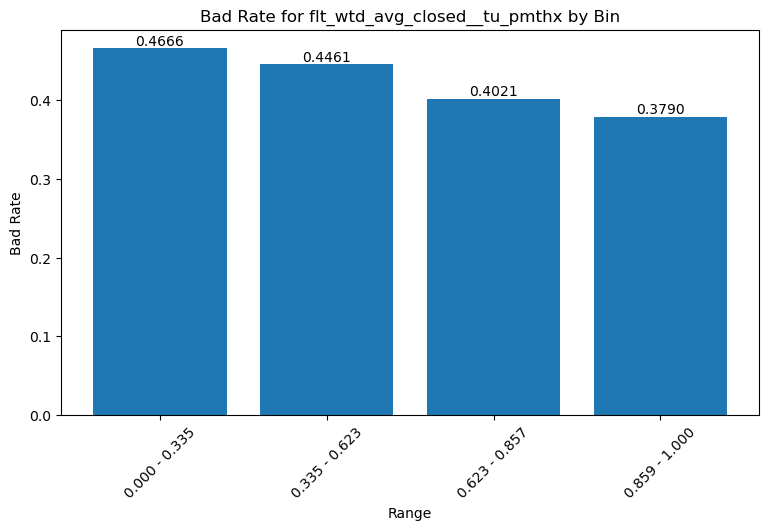

 60%|██████    | 6/10 [00:00<00:00,  7.65it/s]

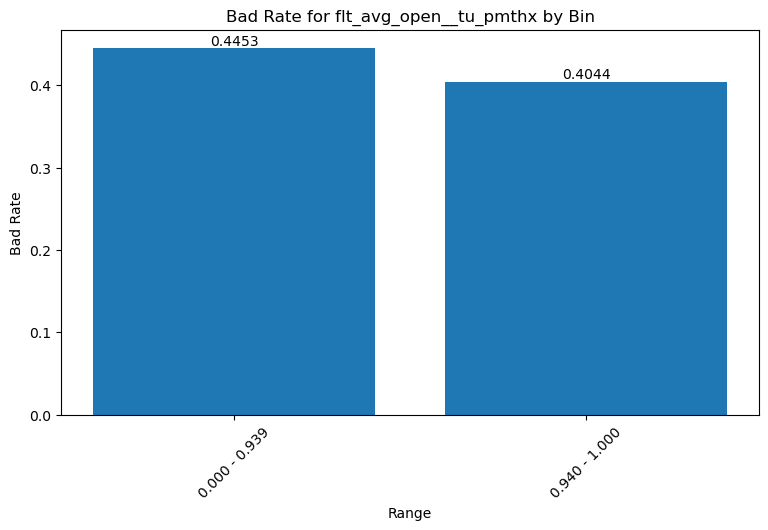

 70%|███████   | 7/10 [00:00<00:00,  8.12it/s]

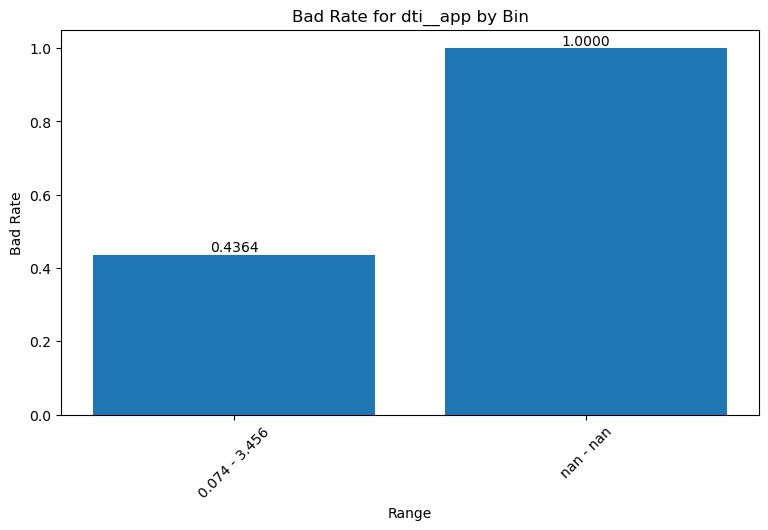

 80%|████████  | 8/10 [00:01<00:00,  8.40it/s]

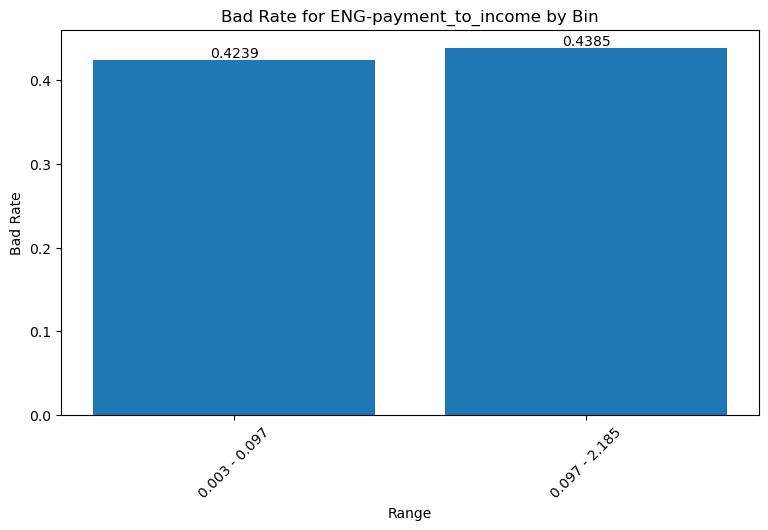

 90%|█████████ | 9/10 [00:01<00:00,  8.66it/s]

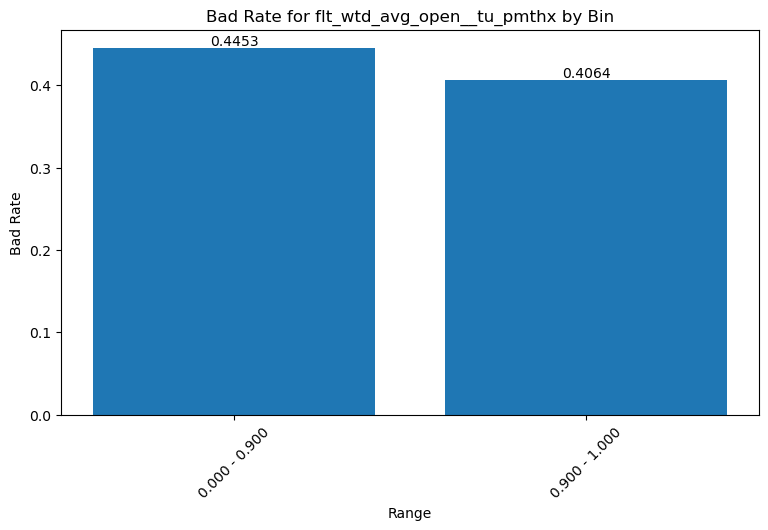

100%|██████████| 10/10 [00:01<00:00,  7.96it/s]


In [10]:
df_bins['label'] = df_bins.apply(
    lambda x: f"{x['min']:0.3f} - {x['max']:0.3f}",
    axis=1,
)

df_bins['feature_tmp'] = df_bins['feature'].apply(
    lambda x: x.split('_binned')[0],
)
list_cols = list(df_bins['feature_tmp'].value_counts().index)
# plot
for col in tqdm(list_cols):
    df_tmp = df_bins[df_bins['feature_tmp'] == col].copy()    
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Bad Rate for {col} by Bin')
    ax.set_xlabel('Range')
    ax.set_ylabel('Bad Rate')
    bars = ax.bar(df_tmp['label'], df_tmp['target'])
    ax.bar_label(bars, fmt='%.4f')
    ax.set_xticklabels(df_tmp['label'], rotation=45)
    plt.show()